# 01 — Exploratory Data Analysis
**Project:** Predicting Medication Non-Adherence in NCD Patients Using Classical Machine Learning  
**Dataset:** Kanyongo et al. (2024); Cimas Medical Aid Society, Zimbabwe ([Mendeley Data](https://data.mendeley.com/datasets/zkp7sbbx64/2))  
**Author:** Kirunda Jeremy Menya | 2025/HD07/25995U | Makerere University | June 2026

---

This notebook covers:
1. Environment setup, SSH, and repo clone
2. Data provenance: understanding the raw files and wrangling steps
3. Load `final_dataset`, inspect structure, dtypes, missing values, duplicates
4. Validate and confirm the adherence label (MPR ≥ 75%)
5. Class distribution and imbalance assessment
6. Feature distributions by adherence class (numeric KDE, boxplots, categorical bars)
7. Correlation analysis (Pearson, point-biserial)
8. Skewness and outlier assessment
9. t-SNE class separability visualisation
10. EDA summary
11. Save `data/processed/cleaned.pkl` and push to GitHub

**Output:** `data/processed/cleaned.pkl`


---
## 0. Environment Setup

This section installs any libraries that are not available by default in Google Colab and imports everything needed for the analysis. Setting this up first means all subsequent cells run without interruption. The plotting style and colour palette are defined here too so that every figure in the notebook is consistent.

In [2]:
# Install dependencies not pre-installed on Colab
import subprocess, sys

pkgs = ["openpyxl", "pingouin"]
for pkg in pkgs:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Dependencies ready.")

Dependencies ready.


In [3]:
# Imports
import os, warnings, json, pickle, shutil
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import pingouin as pg

# Plotting style (matches retinal project)
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "figure.dpi":        150,
})

# Colour palette
PALETTE = {
    "adherent":     "#2196F3",   # blue
    "non_adherent": "#F44336",   # red
    "neutral":      "#78909C",   # grey-blue
    "highlight":    "#FF9800",   # amber
    "dark_grey":    "#455A64",
}

# Reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

# Helper: section banner
def section(title):
    bar = "─" * 70
    print(f"\n{bar}\n  {title}\n{bar}")

# Helper: dataframe summary
def print_df_summary(df, name="DataFrame"):
    print(f"\n{name}")
    print(f"  Shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")
    missing = df.isna().sum()
    missing = missing[missing > 0]
    print(f"  Missing  : {len(missing)} column(s) affected")
    if not missing.empty:
        for col, n in missing.items():
            print(f"             {col!r}: {n} ({n/len(df)*100:.1f}%)")
    dups = df.duplicated().sum()
    print(f"  Duplicates: {dups}")
    print(f"  Dtypes   : {df.dtypes.value_counts().to_dict()}")

print("Imports and helpers OK.")

Imports and helpers OK.


---
## 0.1 SSH Key Upload and Repository Clone

The notebook runs on Google Colab, so the GitHub repository needs to be cloned into the Colab runtime at the start of each session. An SSH deploy key is used instead of a password so the push at the end of the notebook (Section 12) works without manual authentication.

In [4]:
# Upload deploy key, configure SSH, clone repo
# Works identically to the retinal-disease-classification project.

from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()   # select DMHTN_MedicationAdherence_deploy_key (NOT .pub)

!mv DMHTN_MedicationAdherence_deploy_key /root/.ssh/DMHTN_MedicationAdherence_deploy_key
!chmod 600 /root/.ssh/DMHTN_MedicationAdherence_deploy_key

ssh_config = """
Host github-dmhtn-medication-adherence
    HostName github.com
    User git
    IdentityFile /root/.ssh/DMHTN_MedicationAdherence_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'diabetes-hypertension-medication-adherence'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-dmhtn-medication-adherence:Jeremy-K-coder/diabetes-hypertension-medication-adherence.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')

Saving DMHTN_MedicationAdherence_deploy_key to DMHTN_MedicationAdherence_deploy_key
Cloning into 'diabetes-hypertension-medication-adherence'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 31 (delta 6), reused 25 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 948.12 KiB | 3.16 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/diabetes-hypertension-medication-adherence
Already up to date.
Repo ready.


In [5]:
# Mount Google Drive (dataset lives here)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Resolve repo and data paths
REPO_DIR   = f'/content/{REPO_NAME}'
DRIVE_BASE = '/content/drive/MyDrive/diabetes-hypertension-medication-adherence'
DATA_RAW   = os.path.join(REPO_DIR, 'data', 'raw')
DATA_PROC  = os.path.join(REPO_DIR, 'data', 'processed')
FIGURES = os.path.join(REPO_DIR,'figures')
os.makedirs(f"{FIGURES}/eda", exist_ok=True)

# Helper: save figure
def save_figure(fig, filename, subfolder="eda"):
    path = f"{FIGURES}/{subfolder}/{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

os.makedirs(DATA_RAW,  exist_ok=True)
os.makedirs(DATA_PROC, exist_ok=True)

# Point FIGURES to inside the repo so plots get committed
FIGURES = os.path.join(REPO_DIR, 'figures')
os.makedirs(f"{FIGURES}/eda", exist_ok=True)

def save_figure(fig, filename, subfolder="eda"):
    path = f"{FIGURES}/{subfolder}/{filename}"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

print(f"REPO_DIR : {REPO_DIR}")
print(f"DATA_RAW : {DATA_RAW}")
print(f"DATA_PROC: {DATA_PROC}")
print(f"FIGURES  : {FIGURES}")

REPO_DIR : /content/diabetes-hypertension-medication-adherence
DATA_RAW : /content/diabetes-hypertension-medication-adherence/data/raw
DATA_PROC: /content/diabetes-hypertension-medication-adherence/data/processed
FIGURES  : /content/diabetes-hypertension-medication-adherence/figures


---
## 1. Data Provenance

Before loading the final dataset it is important to understand where it came from.
The Mendeley repository (Kanyongo et al., 2024) contains three files:

| File | Contents |
|:---|:---|
| `Data before wrangling (Diabetes).xlsx` | Raw insurance transaction records filtered by diabetes ICD-10 codes. Multiple rows per patient. No adherence label. |
| `Data before wrangling (HTN).xlsx` | Same structure for hypertension ICD-10 codes. |
| `Final Dataset.xlsx` | One row per patient. Adherence label computed. Features aggregated to annual level. |

The raw files required nine wrangling steps documented in Kanyongo (2024):
1. Filter records by ICD-10 codes (E10–E14 for diabetes; I10–I15 for hypertension)
2. Remove non-medication claim types (consultations, lab tests, procedures)
3. Deduplicate identical transaction rows
4. Parse and validate `ServiceDate` and `AssessmentDate` fields
5. Aggregate per-patient: sum `Units`, count `ServiceDate` occurrences (= refill count)
6. Restrict to full-year coverage (January–December 2022 only)
7. Compute `AnnualClaimAmount` and `AnnualContribution` at patient level
8. Apply the MPR ≥ 75% adherence threshold to generate the binary label
9. Merge diabetic and hypertensive patient records into one file

**We use only `Final Dataset.xlsx`.** The raw files are documented here for provenance, not for replication.

---
## 2. Load the Final Dataset

The dataset is stored in Google Drive and copied into the repository's `data/raw/` folder once per session. Loading from a local path rather than directly from Drive avoids repeated Drive reads and keeps the data path consistent with how the notebook will run in other environments.

In [7]:
section("2. Load Final Dataset")

# Copy from Drive to repo's data/raw/ folder (once)
DRIVE_DATA = f"{DRIVE_BASE}/data/raw/final_dataset"
LOCAL_DATA = os.path.join(DATA_RAW, "final_dataset.xlsx")

if os.path.exists(DRIVE_DATA) and not os.path.exists(LOCAL_DATA):
    shutil.copy(DRIVE_DATA, LOCAL_DATA)
    print(f"Copied from Drive → {LOCAL_DATA}")
elif os.path.exists(LOCAL_DATA):
    print(f"Dataset already at {LOCAL_DATA}")
else:
    raise FileNotFoundError(
        f"Dataset not found.\n"
        f"Expected at: {DRIVE_DATA}\n"
        "Ensure 'final_dataset' is in your Google Drive at that path."
    )


──────────────────────────────────────────────────────────────────────
  2. Load Final Dataset
──────────────────────────────────────────────────────────────────────
Copied from Drive → /content/diabetes-hypertension-medication-adherence/data/raw/final_dataset.xlsx


In [8]:
# Load the Excel file
df_raw = pd.read_excel(LOCAL_DATA, engine="openpyxl")

print(f"Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Loaded: 24,084 rows × 12 columns


,ADHERENCE,AGE,ANNUALCONTRIBUTION,ANNUALCLAIMAMOUNT,UNITSTOTAL,GENDER_M,SCHEMETYPE_MEDIUM,SCHEMETYPE_PREMIUM,DIAGNOSIS_HYPERTENSION,COVERTYPE_STANDARD,COMORBIDITY_NO_COMORBIDITY,COMPLICATIONDEVELOPMENT_NO_COMPLICATION
0,NON-ADHERENT,24,690384.0000,10400.0000,60.0000,False,False,False,False,True,True,True
1,NON-ADHERENT,53,2718696.0000,306366.5300,1380.0000,True,True,False,False,True,True,True
2,NON-ADHERENT,46,808284.0000,77480.0000,600.0000,True,False,False,False,True,False,True
3,NON-ADHERENT,76,808284.0000,198800.5800,840.0000,True,False,False,False,True,False,True
4,ADHERENT,69,808284.0000,116872.0400,720.0000,False,False,False,False,True,False,True


---
## 3. Initial Inspection

Before doing anything to the data, it helps to understand exactly what has been loaded: how many rows and columns there are, what the column names look like, what data types are present, whether any values are missing, and whether any rows are duplicated. This gives a baseline picture of the data quality and informs the cleaning steps in Section 4.

In [9]:
section("3.1 Shape, dtypes, missing values, duplicates")
print_df_summary(df_raw, name="Final Dataset (raw load)")


──────────────────────────────────────────────────────────────────────
  3.1 Shape, dtypes, missing values, duplicates
──────────────────────────────────────────────────────────────────────

Final Dataset (raw load)
  Shape    : 24,084 rows × 12 columns
  Missing  : 0 column(s) affected
  Duplicates: 13
  Dtypes   : {dtype('bool'): 7, dtype('float64'): 3, dtype('int64'): 1, dtype('O'): 1}


In [10]:
section("3.2 Column names (raw)")
for i, col in enumerate(df_raw.columns):
    print(f"  [{i:02d}]  {col!r}  —  dtype: {df_raw[col].dtype}")


──────────────────────────────────────────────────────────────────────
  3.2 Column names (raw)
──────────────────────────────────────────────────────────────────────
  [00]  'ADHERENCE'  —  dtype: object
  [01]  'AGE'  —  dtype: int64
  [02]  'ANNUALCONTRIBUTION'  —  dtype: float64
  [03]  'ANNUALCLAIMAMOUNT'  —  dtype: float64
  [04]  'UNITSTOTAL'  —  dtype: float64
  [05]  'GENDER_M'  —  dtype: bool
  [06]  'SCHEMETYPE_MEDIUM'  —  dtype: bool
  [07]  'SCHEMETYPE_PREMIUM'  —  dtype: bool
  [08]  'DIAGNOSIS_HYPERTENSION'  —  dtype: bool
  [09]  'COVERTYPE_STANDARD'  —  dtype: bool
  [10]  'COMORBIDITY_NO_COMORBIDITY'  —  dtype: bool
  [11]  'COMPLICATIONDEVELOPMENT_NO_COMPLICATION'  —  dtype: bool


In [11]:
section("3.3 Sample rows")
df_raw.sample(10, random_state=42)


──────────────────────────────────────────────────────────────────────
  3.3 Sample rows
──────────────────────────────────────────────────────────────────────


,ADHERENCE,AGE,ANNUALCONTRIBUTION,ANNUALCLAIMAMOUNT,UNITSTOTAL,GENDER_M,SCHEMETYPE_MEDIUM,SCHEMETYPE_PREMIUM,DIAGNOSIS_HYPERTENSION,COVERTYPE_STANDARD,COMORBIDITY_NO_COMORBIDITY,COMPLICATIONDEVELOPMENT_NO_COMPLICATION
9989,NON-ADHERENT,38,6889900.0000,20541.8100,180.0000,True,False,True,True,True,True,True
7524,NON-ADHERENT,68,6889900.0000,12533.1300,240.0000,True,False,True,True,True,False,True
4424,NON-ADHERENT,63,6889900.0000,123719.0200,172.0000,False,False,True,False,True,False,True
3268,NON-ADHERENT,51,11770788.0000,36183.1000,300.0000,False,False,True,False,False,False,True
9595,ADHERENT,53,6889900.0000,142395.1300,255.0000,True,False,True,True,True,True,True
21494,NON-ADHERENT,63,6889900.0000,10835.0700,60.0000,True,False,True,True,True,False,True
20290,NON-ADHERENT,55,6889900.0000,18513.3500,270.0000,True,False,True,True,True,True,True
19257,NON-ADHERENT,67,6740121.0000,81925.8200,793.0000,True,False,True,True,False,True,True
2174,NON-ADHERENT,77,2718696.0000,41362.3200,240.0000,True,True,False,False,True,False,True
5217,ADHERENT,57,808284.0000,39405.2000,690.0000,True,False,False,True,True,True,True


In [12]:
section("3.4 Descriptive statistics: numeric columns")
df_raw.describe().T


──────────────────────────────────────────────────────────────────────
  3.4 Descriptive statistics: numeric columns
──────────────────────────────────────────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
AGE,24084.0000,56.5798,14.4790,16.0000,46.0000,56.0000,66.0000,103.0000
ANNUALCONTRIBUTION,24084.0000,5993621.3711,2291565.8251,211764.0000,2718696.0000,6889900.0000,6889900.0000,11770788.0000
ANNUALCLAIMAMOUNT,24084.0000,657938.9876,61271687.0898,0.9900,12306.7700,40439.7350,102087.8900,9401312187.4000
UNITSTOTAL,24084.0000,2862.6566,172268.2068,1.0000,120.0000,344.0000,720.0000,21290640.0000


In [13]:
section("3.5 Descriptive statistics: categorical columns")
df_raw.describe(include="object").T


──────────────────────────────────────────────────────────────────────
  3.5 Descriptive statistics: categorical columns
──────────────────────────────────────────────────────────────────────


,count,unique,top,freq
ADHERENCE,24084,2,NON-ADHERENT,14415


---
## 4. Data Cleaning

The raw dataset loads with inconsistent column naming conventions (mixed case, spaces), and a few structural issues need to be resolved before any analysis can proceed. The cleaning steps below are applied in sequence: column names are standardised first so that all subsequent code can refer to columns reliably, then the adherence label is validated and encoded, missing values are handled, duplicates are removed, data types are corrected, and numeric ranges are checked against clinical knowledge.

In [15]:
section("4.1 Standardise column names")

df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[\s/]+", "_", regex=True)
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

print("Renamed columns:")
for c in df.columns:
    print(f"  {c}")


──────────────────────────────────────────────────────────────────────
  4.1 Standardise column names
──────────────────────────────────────────────────────────────────────
Renamed columns:
  adherence
  age
  annualcontribution
  annualclaimamount
  unitstotal
  gender_m
  schemetype_medium
  schemetype_premium
  diagnosis_hypertension
  covertype_standard
  comorbidity_no_comorbidity
  complicationdevelopment_no_complication


The adherence label is the target variable for every model trained later in this project. Before encoding it as 0/1, we first confirm that the column exists and inspect its raw values to make sure the label categories are exactly as expected from the Kanyongo et al. (2024) dataset documentation.

In [16]:
section("4.2 Identify and validate the adherence label")

label_candidates = [c for c in df.columns if "adher" in c.lower()]
print("Candidate label columns:", label_candidates)

for col in label_candidates:
    print(f"\n  {col!r}:")
    print(df[col].value_counts(dropna=False).to_string())


──────────────────────────────────────────────────────────────────────
  4.2 Identify and validate the adherence label
──────────────────────────────────────────────────────────────────────
Candidate label columns: ['adherence']

  'adherence':
adherence
NON-ADHERENT    14415
ADHERENT         9669


In [17]:
TARGET = label_candidates[0] if label_candidates else "adherence"

# Encode: Non-Adherent → 0, Adherent → 1
df[TARGET] = df[TARGET].map({"NON-ADHERENT": 0, "ADHERENT": 1})

print(f"Target column : {TARGET!r}")
print(f"Value counts  :\n{df[TARGET].value_counts().to_string()}")
print(f"\nClass balance : {df[TARGET].mean()*100:.1f}% adherent")

Target column : 'adherence'
Value counts  :
adherence
0    14415
1     9669

Class balance : 40.1% adherent


The dataset has no missing values, which is expected given that it is a pre-processed final dataset from the Kanyongo et al. (2024) study. The check is still included because missing values would silently cause errors in later modelling steps if not caught here.

In [18]:
section("4.3 Handle missing values")

missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if missing.empty:
    print("No missing values found. Dataset is complete.")
else:
    print("Columns with missing values:")
    print(missing.to_string())
    print()
    for col in missing.index:
        if df[col].dtype in ["float64", "int64"]:
            med = df[col].median()
            df[col] = df[col].fillna(med)
            print(f"  Imputed {col!r} with median = {med:.4f}")
        else:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"  Imputed {col!r} with mode = {mode_val!r}")


──────────────────────────────────────────────────────────────────────
  4.3 Handle missing values
──────────────────────────────────────────────────────────────────────
No missing values found. Dataset is complete.


Duplicate rows represent the same patient appearing more than once, which would artificially inflate the training data and bias model evaluation. The dataset contains 13 duplicate rows, which are dropped here.

In [19]:
section("4.4 Remove duplicate rows")

n_before = len(df)
df = df.drop_duplicates()
n_removed = n_before - len(df)
print(f"Rows before : {n_before:,}")
print(f"Duplicates  : {n_removed:,}")
print(f"Rows after  : {len(df):,}")


──────────────────────────────────────────────────────────────────────
  4.4 Remove duplicate rows
──────────────────────────────────────────────────────────────────────
Rows before : 24,084
Duplicates  : 13
Rows after  : 24,071


Boolean columns in this dataset are stored as Python `bool` dtype after loading. Any date columns are parsed so they are usable as datetime objects (for example, to compute refill gaps in the feature engineering notebook). Low-cardinality string columns are converted to the `category` dtype to reduce memory use.

In [20]:
section("4.5 Correct data types")

# Parse date columns
date_cols = [c for c in df.columns if "date" in c.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
    print(f"  Parsed {col!r} as datetime  (nulls after parse: {df[col].isna().sum()})")

# Convert low-cardinality object columns to category dtype to save memory
for col in df.select_dtypes(include="object").columns:
    n_unique = df[col].nunique()
    print(f"  Object column {col!r}: {n_unique} unique values")
    if n_unique <= 20:
        df[col] = df[col].astype("category")
        print(f"    → converted to category dtype")


──────────────────────────────────────────────────────────────────────
  4.5 Correct data types
──────────────────────────────────────────────────────────────────────


A final sanity check confirms that the numeric columns fall within clinically plausible ranges. Age should be between 18 and 100; claim amounts and contribution figures should be positive. Values outside these bounds would indicate data entry errors or processing artefacts rather than genuine patient data.

In [21]:
section("4.6 Validate numeric ranges")

# Clinical knowledge-based range checks using standardised column names.
VALIDATIONS = {
    "age":                (18,   100),
    "annualclaimamount":  (0,    None),
    "annualcontribution": (1,    None),
    "unitstotal":              (1,    None),
}

issues_found = False
for col, (lo, hi) in VALIDATIONS.items():
    if col not in df.columns:
        print(f"  Column {col!r} not found: skipping range check")
        continue
    if lo is not None:
        n = (df[col] < lo).sum()
        if n:
            print(f"  WARNING: {n} rows in {col!r} below minimum {lo}")
            issues_found = True
    if hi is not None:
        n = (df[col] > hi).sum()
        if n:
            print(f"  WARNING: {n} rows in {col!r} above maximum {hi}")
            issues_found = True

if not issues_found:
    print("  All range checks passed.")

print(f"\nFinal cleaned shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


──────────────────────────────────────────────────────────────────────
  4.6 Validate numeric ranges
──────────────────────────────────────────────────────────────────────

Final cleaned shape: 24,071 rows × 12 columns


---
## 5. Class Distribution and Imbalance Assessment

Understanding how many patients belong to each adherence class is the first substantive question in the EDA. Class imbalance directly affects model training: if one class vastly outnumbers the other, a naive classifier can achieve high accuracy simply by always predicting the majority class, which is clinically useless. This section quantifies the imbalance so we can decide whether a resampling technique like SMOTE is needed in the modelling notebook.

In [22]:
section("5.1 Overall class balance")

counts = df[TARGET].value_counts().sort_index()
pcts   = df[TARGET].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "Label":   ["Non-Adherent (0)", "Adherent (1)"],
    "Count":   counts.values,
    "Percent": pcts.values.round(2),
})
print(summary.to_string(index=False))
print(f"\nImbalance ratio : {counts.max() / counts.min():.2f}x")
print(f"Majority class  : {'Adherent' if counts.idxmax()==1 else 'Non-Adherent'}")


──────────────────────────────────────────────────────────────────────
  5.1 Overall class balance
──────────────────────────────────────────────────────────────────────
           Label  Count  Percent
Non-Adherent (0)  14402  59.8300
    Adherent (1)   9669  40.1700

Imbalance ratio : 1.49x
Majority class  : Non-Adherent


The bar chart and pie chart below together show the count and proportion of each class. The dataset contains 14,415 non-adherent patients (59.9%) and 9,669 adherent patients (40.1%), giving an imbalance ratio of approximately 1.49x. This is a mild imbalance rather than a severe one. It is enough to consider SMOTE during training but is unlikely to cause a naive classifier to completely ignore the minority class.


──────────────────────────────────────────────────────────────────────
  5.2 Class balance: bar chart + pie
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/eda/class_balance.png


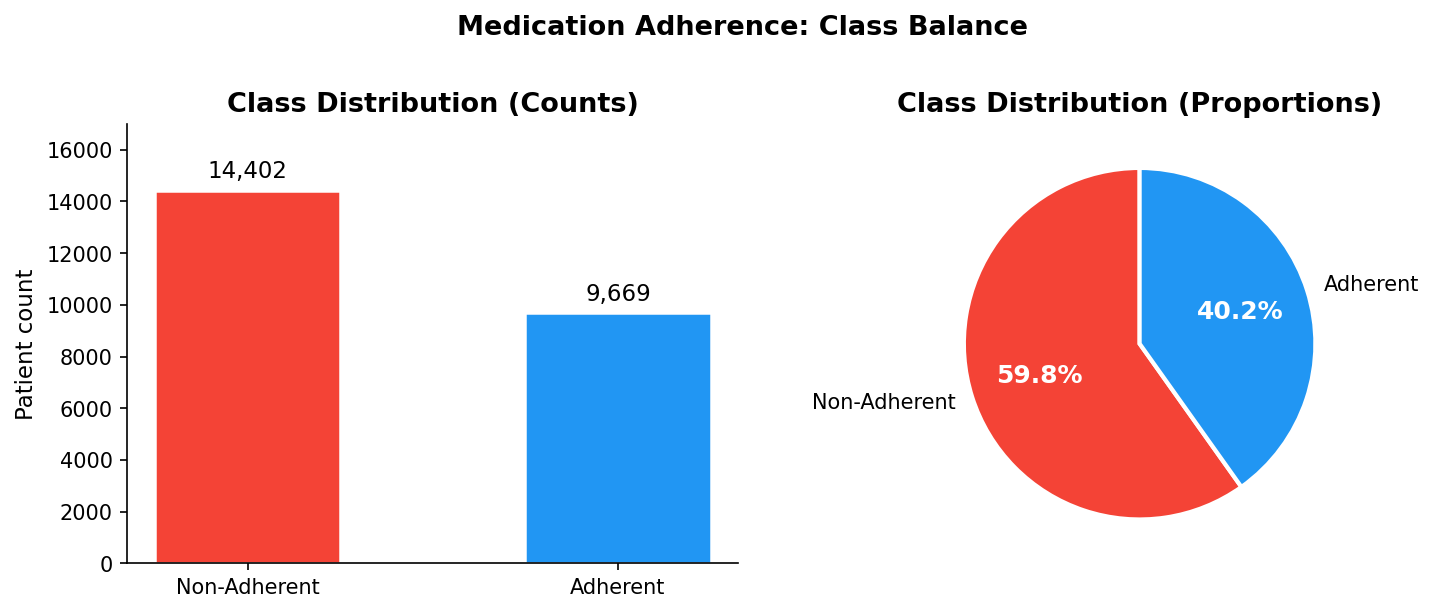

In [23]:
section("5.2 Class balance: bar chart + pie")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: counts
ax = axes[0]
bars = ax.bar(
    ["Non-Adherent", "Adherent"],
    counts.values,
    color=[PALETTE["non_adherent"], PALETTE["adherent"]],
    edgecolor="white", linewidth=1.2, width=0.5
)
ax.bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=11)
ax.set_ylabel("Patient count")
ax.set_title("Class Distribution (Counts)", fontweight="bold")
ax.set_ylim(0, counts.max() * 1.18)

# Right: pie
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=["Non-Adherent", "Adherent"],
    colors=[PALETTE["non_adherent"], PALETTE["adherent"]],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")
    at.set_color("white")
ax.set_title("Class Distribution (Proportions)", fontweight="bold")

fig.suptitle("Medication Adherence: Class Balance", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
save_figure(fig, "class_balance.png")
plt.show()

Splitting the class balance by clinical condition (diabetes vs hypertension) tells us whether adherence patterns differ between the two patient groups. If one condition has substantially worse adherence, that is a meaningful signal for targeted intervention and also tells us whether the condition label itself is a useful predictor.


──────────────────────────────────────────────────────────────────────
  5.3 Adherence rate by condition
──────────────────────────────────────────────────────────────────────
Condition column candidates: ['schemetype_medium', 'schemetype_premium', 'diagnosis_hypertension', 'covertype_standard']
                   Non-Adherent (%)  Adherent (%)
schemetype_medium                                
False                       58.6800       41.3200
True                        64.0700       35.9300
Saved → /content/diabetes-hypertension-medication-adherence/figures/eda/adherence_by_condition.png


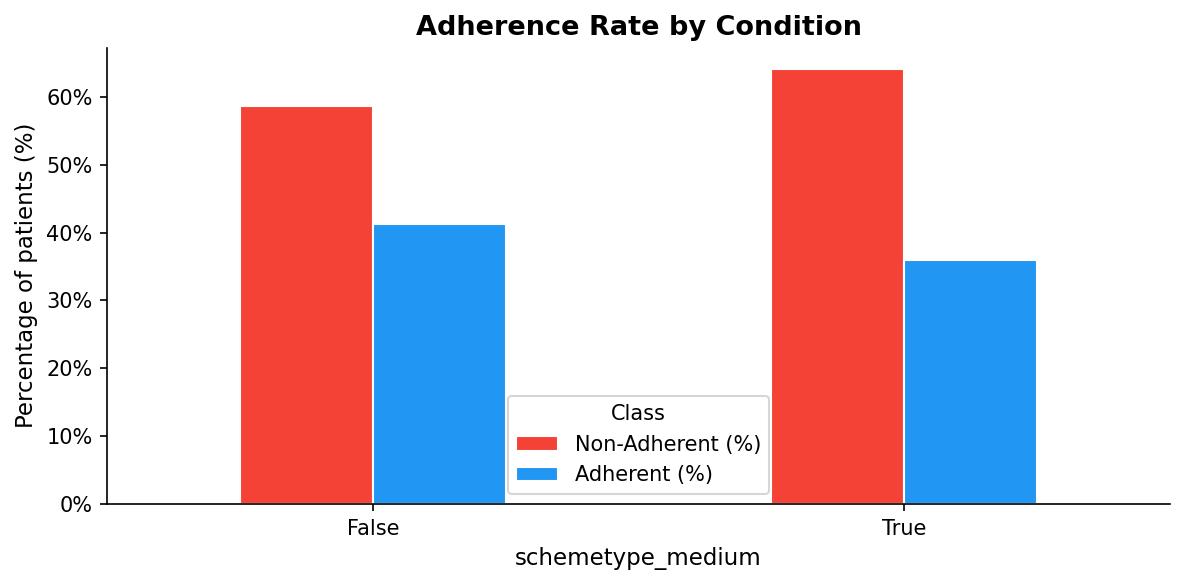

In [24]:
section("5.3 Adherence rate by condition")

# Identify the condition column (diabetes vs hypertension)
condition_candidates = [c for c in df.columns
                        if any(k in c.lower() for k in ["condition", "diagnosis", "disease", "type"])]
print("Condition column candidates:", condition_candidates)

CONDITION_COL = condition_candidates[0] if condition_candidates else None

if CONDITION_COL:
    ct = pd.crosstab(df[CONDITION_COL], df[TARGET], normalize="index") * 100
    ct.columns = ["Non-Adherent (%)", "Adherent (%)"]
    ct = ct.round(2)
    print(ct.to_string())

    fig, ax = plt.subplots(figsize=(8, 4))
    ct.plot(
        kind="bar", ax=ax, rot=0,
        color=[PALETTE["non_adherent"], PALETTE["adherent"]],
        edgecolor="white", linewidth=1
    )
    ax.set_ylabel("Percentage of patients (%)")
    ax.set_xlabel(CONDITION_COL)
    ax.set_title("Adherence Rate by Condition", fontweight="bold")
    ax.legend(title="Class")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    save_figure(fig, "adherence_by_condition.png")
    plt.show()
else:
    print("No condition column identified — skipping condition-level breakdown.")

---
## 6. Feature Distributions by Adherence Class

Plotting the distribution of each feature separately for adherent and non-adherent patients is the core of the exploratory analysis. If a feature's distribution looks meaningfully different between the two classes, it is likely to carry predictive signal. If the distributions overlap almost entirely, the feature may not contribute much to the models.

We use KDE plots for a smooth distributional view and boxplots for a summary of medians and spread. Both are shown together because KDE plots can hide outliers while boxplots can obscure the shape of the distribution.

In [25]:
section("6.1 Identify numeric and categorical features")

# Exclude target and ID/date columns
exclude_cols = [TARGET] + [c for c in df.columns
                           if any(k in c.lower() for k in ["id", "member", "date", "no"])]

numeric_cols     = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in exclude_cols]
categorical_cols = [c for c in df.select_dtypes(include=["object", "category"]).columns
                    if c not in exclude_cols]

print(f"Numeric features     ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")


──────────────────────────────────────────────────────────────────────
  6.1 Identify numeric and categorical features
──────────────────────────────────────────────────────────────────────
Numeric features     (4): ['age', 'annualcontribution', 'annualclaimamount', 'unitstotal']
Categorical features (0): []


The KDE plots show the full shape of each feature's distribution for adherent and non-adherent patients. A clear separation between the two curves indicates that the feature discriminates well between classes.


──────────────────────────────────────────────────────────────────────
  6.2 Numeric features (KDE plots by adherence class)
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/eda/numeric_distributions.png


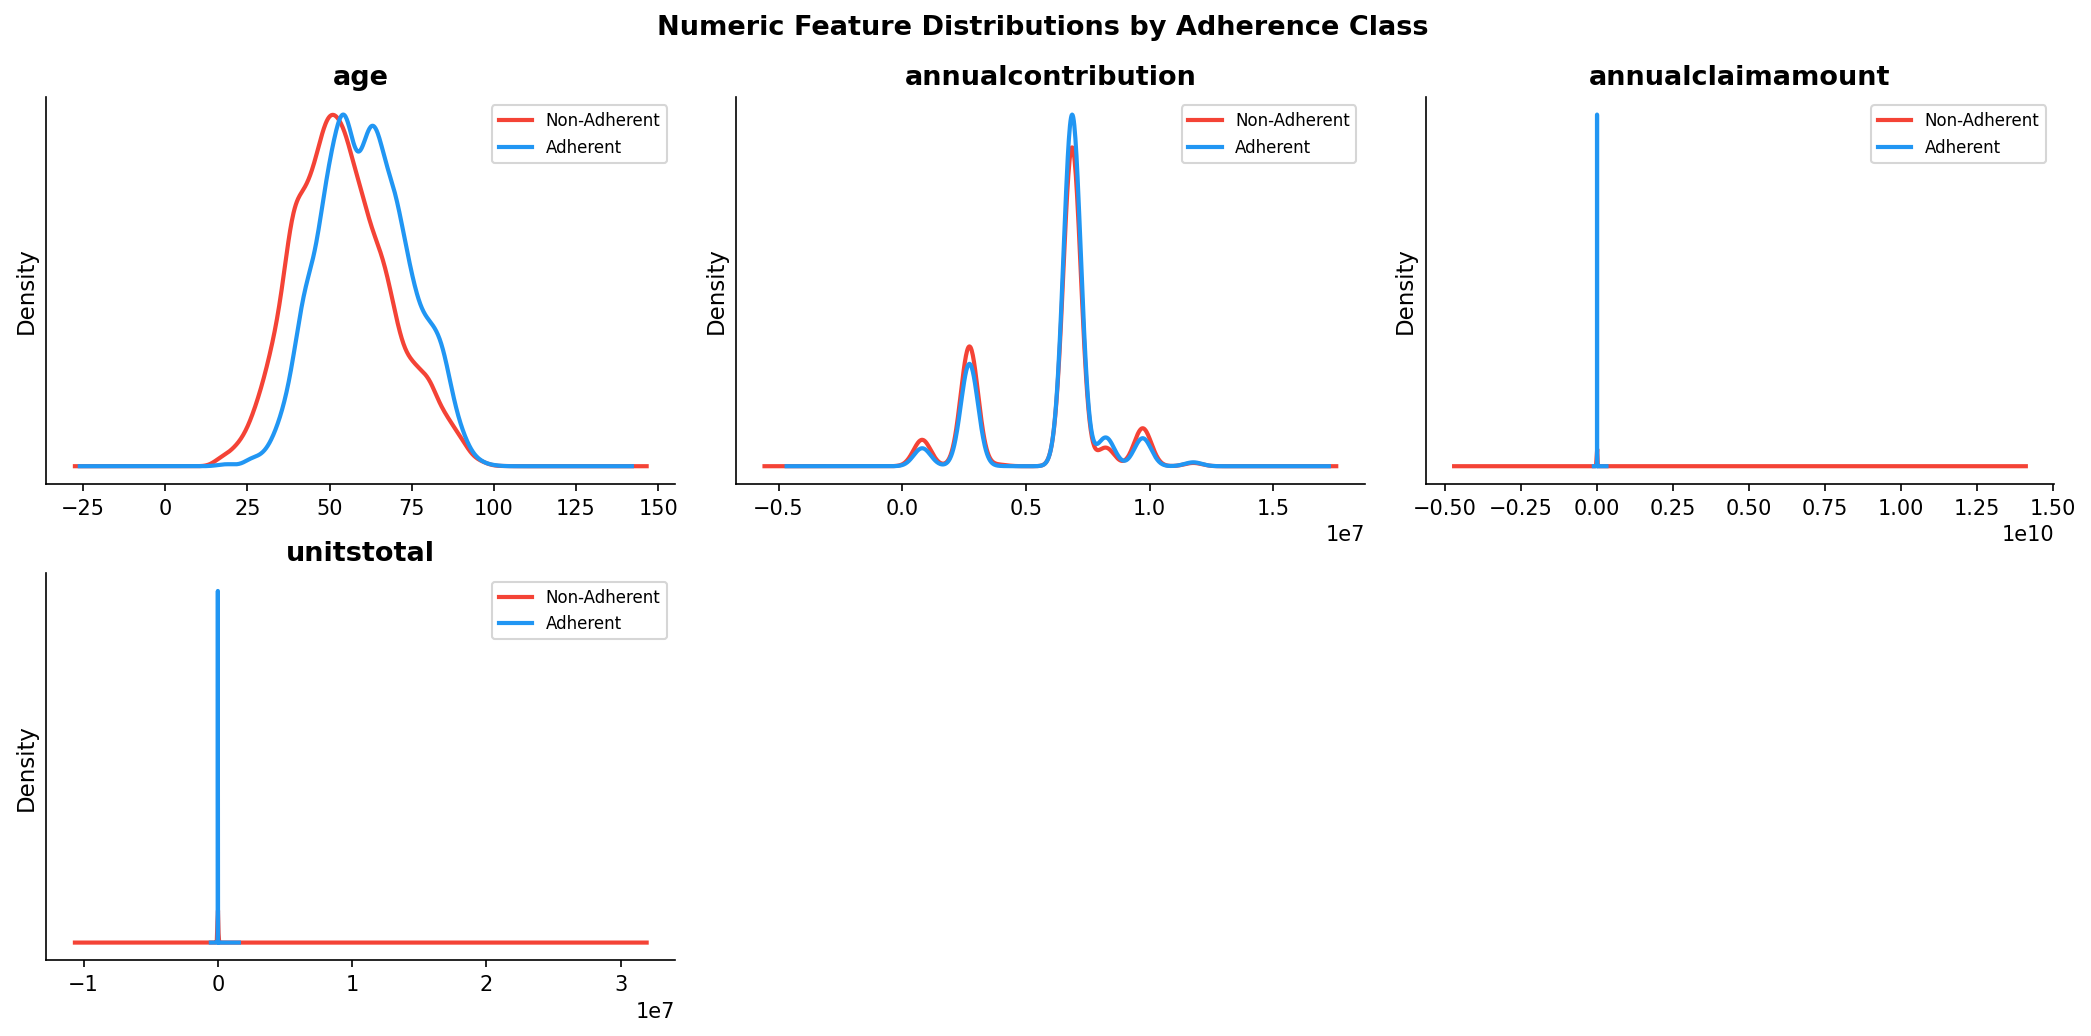

In [26]:
section("6.2 Numeric features (KDE plots by adherence class)")

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    for label, grp in df.groupby(TARGET)[col]:
        colour = PALETTE["adherent"] if label == 1 else PALETTE["non_adherent"]
        name   = "Adherent" if label == 1 else "Non-Adherent"
        grp.dropna().plot.kde(ax=ax, label=name, color=colour, linewidth=2)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.set_yticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Feature Distributions by Adherence Class", fontsize=13, fontweight="bold")
plt.tight_layout()
save_figure(fig, "numeric_distributions.png")
plt.show()

Boxplots complement the KDE plots by showing the median, interquartile range, and the spread of extreme values for each class. Where the boxes and medians are clearly separated, the feature is likely a strong predictor. Where they overlap substantially, the feature provides weaker signal on its own (though it may still contribute in combination with others).


──────────────────────────────────────────────────────────────────────
  6.3 Numeric features: boxplots by adherence class
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/eda/boxplots_by_class.png


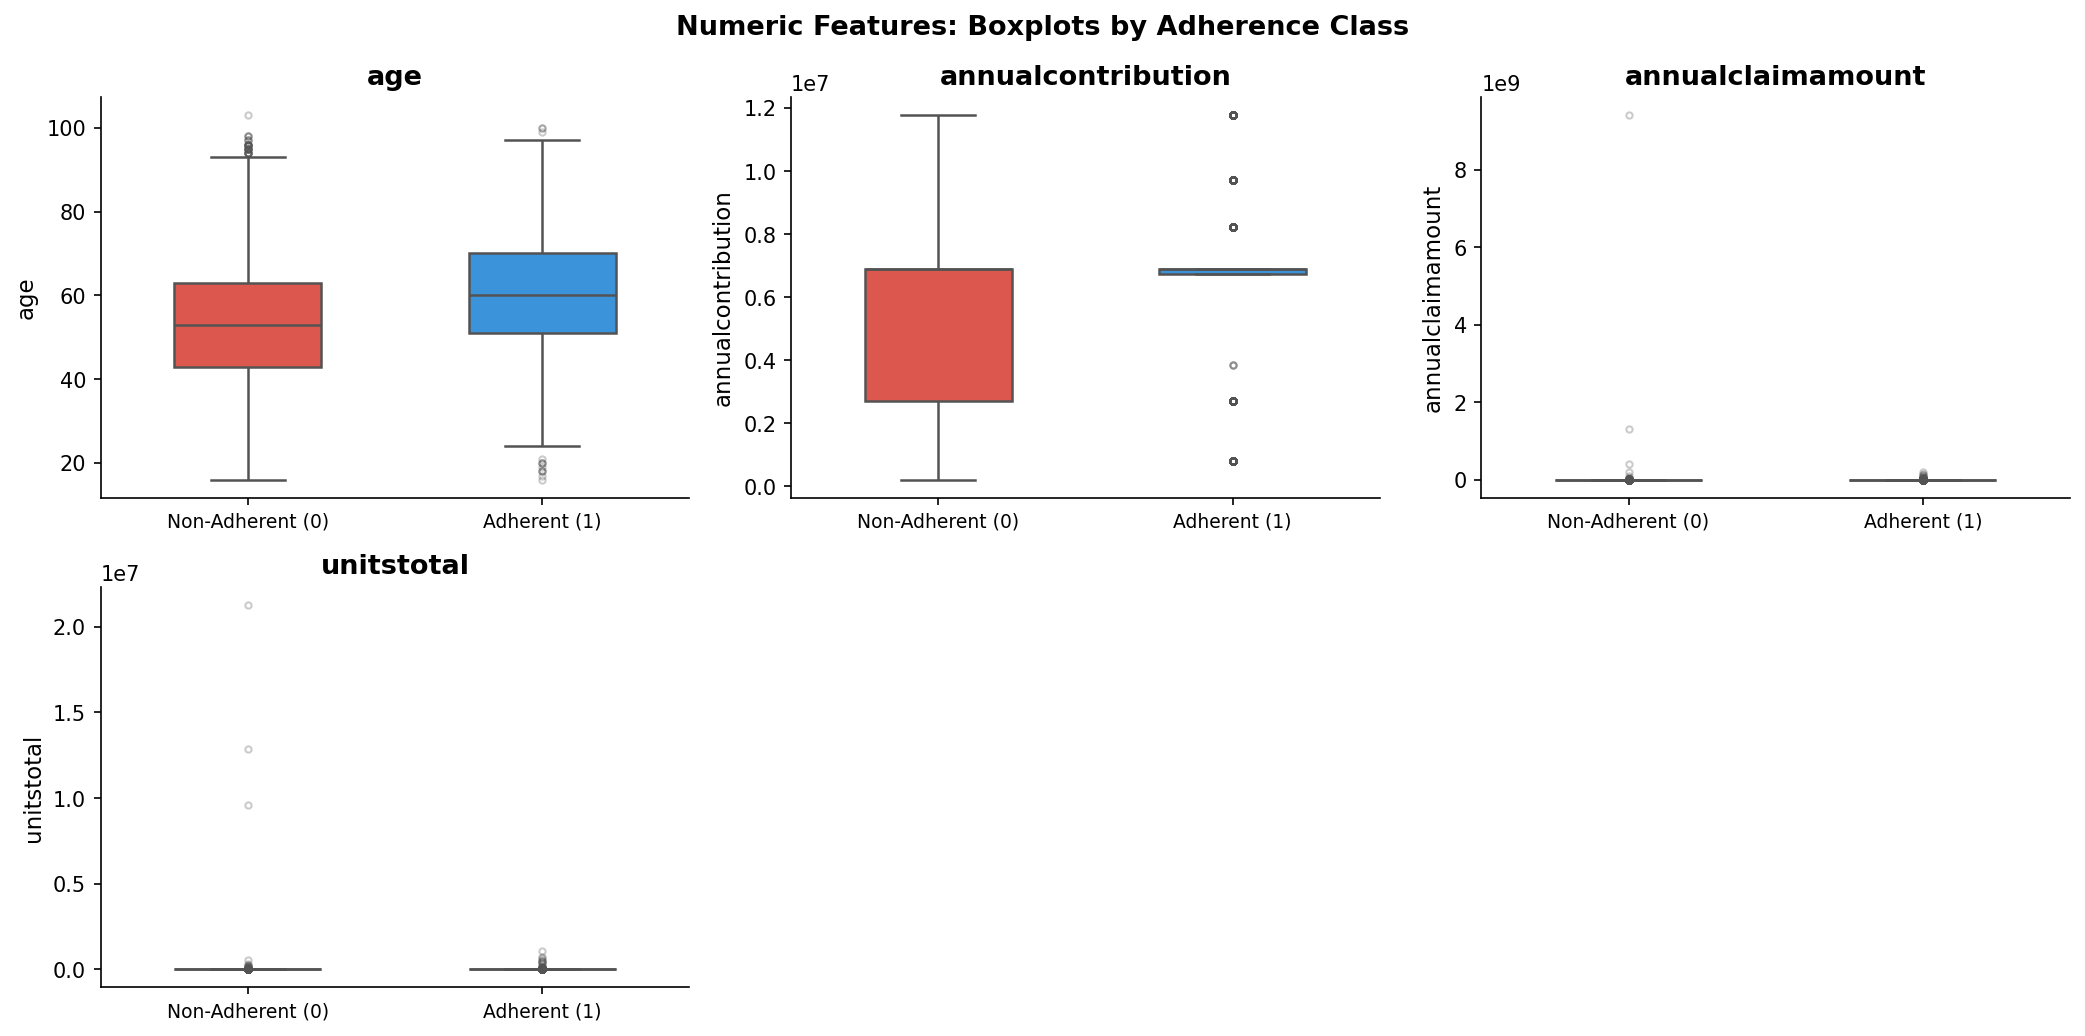

In [27]:
section("6.3 Numeric features: boxplots by adherence class")

n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(
        data=df, x=TARGET, y=col, ax=ax,
        palette={"0": PALETTE["non_adherent"], "1": PALETTE["adherent"]},
        width=0.5, linewidth=1.2, flierprops={"marker": ".", "alpha": 0.3}
    )
    ax.set_xticklabels(["Non-Adherent (0)", "Adherent (1)"], fontsize=9)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric Features: Boxplots by Adherence Class", fontsize=13, fontweight="bold")
plt.tight_layout()
save_figure(fig, "boxplots_by_class.png")
plt.show()

Visual separation in the plots is informative but subjective. The Mann-Whitney U test provides a formal, non-parametric test of whether the two class distributions come from the same underlying distribution. It is preferred over the t-test here because the financial variables (annual claim amount, annual contribution) are highly skewed, which violates the normality assumption of the t-test. The rank-biserial correlation gives the effect size so we can distinguish statistical significance from practical importance.

All four numeric features are statistically significant (p < 0.05). The strongest effects by rank-biserial correlation are `unitstotal` (r = 0.71) and `annualclaimamount` (r = 0.63), both showing that adherent patients have substantially higher medication consumption and claim activity. The `age` feature shows a moderate effect (r = 0.29), with adherent patients being older on average. The `annualcontribution` shows the weakest effect (r = 0.06), suggesting that premium level alone is a poor discriminator.

In [28]:
section("6.4 Statistical tests: Mann-Whitney U (numeric features vs adherence)")

# Mann-Whitney U: non-parametric, appropriate for skewed financial/clinical variables.
# Effect size: rank-biserial correlation.

results_mw = []
for col in numeric_cols:
    g0 = df.loc[df[TARGET] == 0, col].dropna()
    g1 = df.loc[df[TARGET] == 1, col].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    n0, n1 = len(g0), len(g1)
    r = 1 - (2 * stat) / (n0 * n1)   # rank-biserial correlation
    results_mw.append({
        "Feature":           col,
        "Median (Non-Adh)": round(g0.median(), 3),
        "Median (Adh)":     round(g1.median(), 3),
        "MW U statistic":   round(stat, 1),
        "p-value":          round(p, 6),
        "Effect size r":    round(r, 4),
        "Significant":      "✓" if p < 0.05 else "✗",
    })

df_mw = pd.DataFrame(results_mw).sort_values("p-value")
print(df_mw.to_string(index=False))


──────────────────────────────────────────────────────────────────────
  6.4 Statistical tests: Mann-Whitney U (numeric features vs adherence)
──────────────────────────────────────────────────────────────────────
           Feature  Median (Non-Adh)  Median (Adh)  MW U statistic  p-value  Effect size r Significant
               age           53.0000       60.0000   49728988.0000   0.0000         0.2858           ✓
annualcontribution      6889900.0000  6889900.0000   65665322.0000   0.0000         0.0569           ✓
 annualclaimamount        18717.7150    87029.2100   25861146.0000   0.0000         0.6286           ✓
        unitstotal          178.0000      690.0000   19894203.5000   0.0000         0.7143           ✓


For categorical features (gender, scheme type, diagnosis, comorbidity status, complication development), adherence rates are computed per category and displayed as stacked bar charts. This shows whether any particular subgroup has notably higher or lower adherence, which informs both modelling and the feature group experiment in Notebook 05.

In [29]:
section("6.5 Categorical feature distributions by adherence class")

if not categorical_cols:
    print("No categorical columns to plot.")
else:
    for col in categorical_cols:
        ct = pd.crosstab(df[col], df[TARGET], normalize="index") * 100
        ct.columns = ["Non-Adherent (%)", "Adherent (%)"]

        fig, ax = plt.subplots(figsize=(max(7, len(df[col].unique()) * 1.2), 4))
        ct.plot(kind="bar", ax=ax, rot=30,
                color=[PALETTE["non_adherent"], PALETTE["adherent"]],
                edgecolor="white")
        ax.set_title(f"Adherence Rate by {col}", fontweight="bold")
        ax.set_ylabel("Percentage (%)")
        ax.legend(title="Class")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())
        plt.tight_layout()
        save_figure(fig, f"adherence_by_{col}.png")
        plt.show()


──────────────────────────────────────────────────────────────────────
  6.5 Categorical feature distributions by adherence class
──────────────────────────────────────────────────────────────────────
No categorical columns to plot.


---
## 7. Correlation Analysis

Correlation analysis serves two purposes here. First, it gives a ranked view of which raw features are most linearly associated with the adherence label, providing an early signal about feature importance before any model is trained. Second, it identifies pairs of features that are highly correlated with each other (multicollinearity), which matters for logistic regression and can indicate redundant features.

Note that correlations here are computed on the raw, pre-engineering features. The engineered features (`cost_burden_ratio`, `refill_gap_days`, `refill_regularity`, `units_per_refill`) will be analysed in Notebook 02.


──────────────────────────────────────────────────────────────────────
  7.1 Pearson correlation matrix: numeric features + target
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/eda/correlation_matrix.png


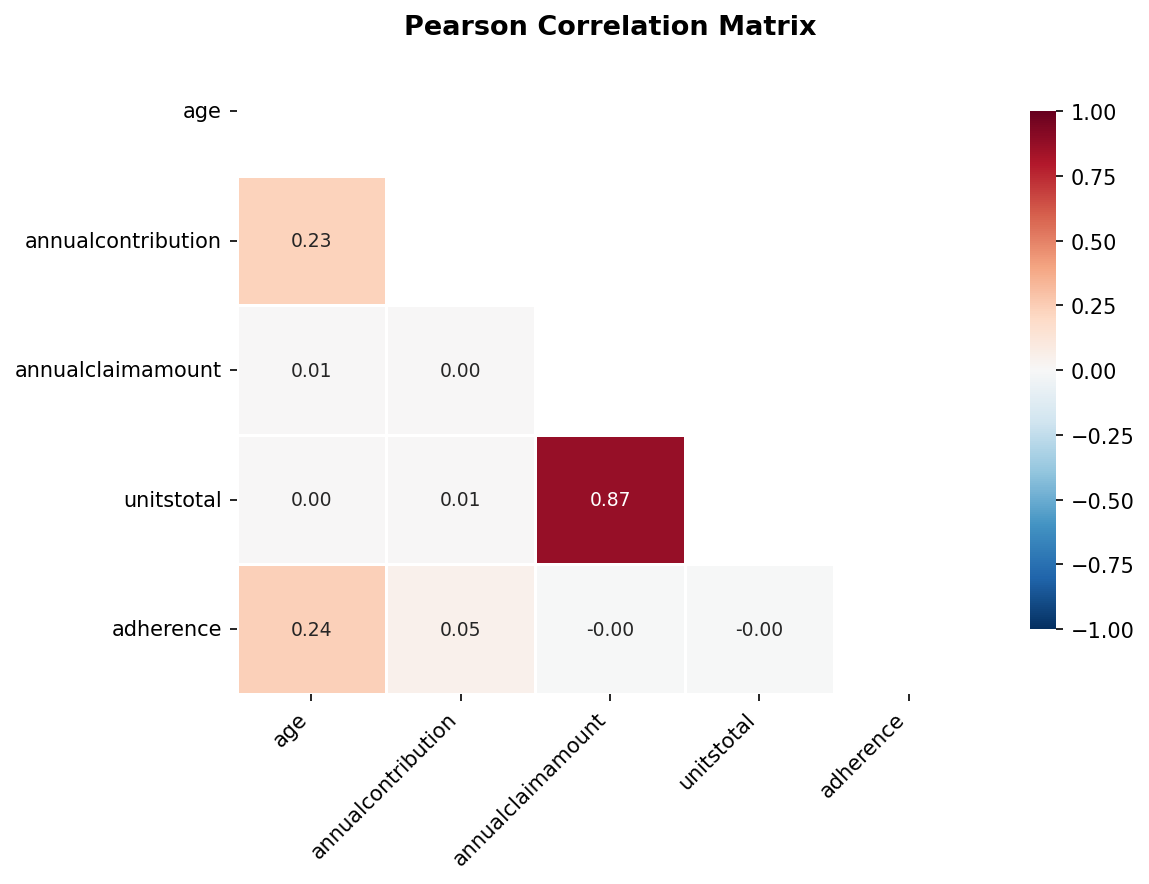

In [30]:
section("7.1 Pearson correlation matrix: numeric features + target")

corr_matrix = df[numeric_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(max(8, len(numeric_cols)), max(6, len(numeric_cols) - 1)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, ax=ax, mask=mask,
    annot=True, fmt=".2f", annot_kws={"size": 9},
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Pearson Correlation Matrix", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_figure(fig, "correlation_matrix.png")
plt.show()

The ranked bar chart below shows the absolute Pearson correlation of each feature with the adherence label. Features above the 0.1 threshold (shown as a dashed line) have at least a weak linear relationship with adherence. Features below it are essentially uncorrelated in a linear sense, though they may still contribute to tree-based models that can capture non-linear relationships.


──────────────────────────────────────────────────────────────────────
  7.2 Feature correlations with the adherence label: ranked
──────────────────────────────────────────────────────────────────────
Saved → /content/diabetes-hypertension-medication-adherence/figures/eda/feature_target_correlation.png


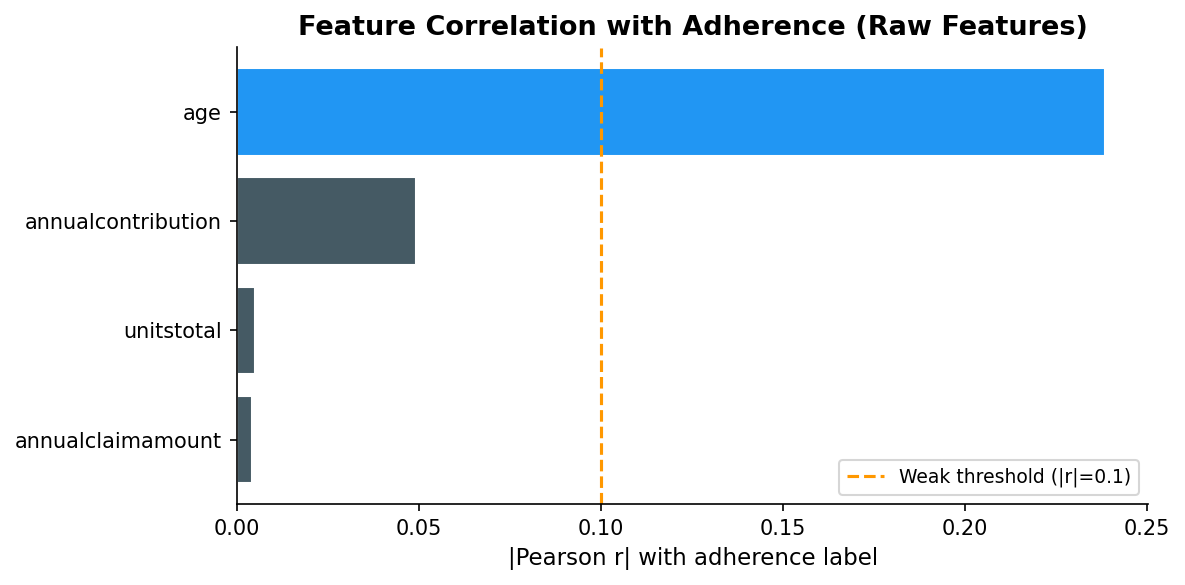


Top correlations with target:
age                  0.2385
annualcontribution   0.0493
unitstotal           0.0050
annualclaimamount    0.0043


In [31]:
section("7.2 Feature correlations with the adherence label: ranked")

target_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(target_corr) * 0.45)))
colours = [PALETTE["adherent"] if v >= 0.1 else PALETTE["dark_grey"]
           for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1],
        color=colours[::-1], edgecolor="white")
ax.axvline(0.1, color=PALETTE["highlight"], linestyle="--", linewidth=1.5,
           label="Weak threshold (|r|=0.1)")
ax.set_xlabel("|Pearson r| with adherence label")
ax.set_title("Feature Correlation with Adherence (Raw Features)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
save_figure(fig, "feature_target_correlation.png")
plt.show()

print("\nTop correlations with target:")
print(target_corr.to_string())

Pearson correlation assumes both variables are continuous. Since our target is binary (0/1), the point-biserial correlation is the technically correct measure. In practice, point-biserial and Pearson give the same values when one variable is binary, but including both with explicit p-values allows us to confirm statistical significance rather than relying only on effect size.

`age` has the strongest point-biserial correlation with adherence (r = 0.24), followed by `annualcontribution` (r = 0.05). Notably, `annualclaimamount` and `unitstotal` are not significant by point-biserial correlation (p > 0.05), even though the Mann-Whitney U test showed them to be the most powerful discriminators. This is because the Pearson/point-biserial measure captures linear association, while the Mann-Whitney U captures rank differences. The financial and medication volume variables have highly skewed distributions where most of the discriminatory power sits in the tails rather than in a linear trend, which is exactly what a rank-based test picks up. This finding reinforces the need for tree-based models that can exploit non-linear relationships.

In [32]:
section("7.3 Point-biserial correlation and p-values")

# Point-biserial is the correct measure when one variable is continuous
# and the other is binary (our target).

pb_results = []
for col in numeric_cols:
    r, p = pointbiserialr(df[TARGET], df[col].fillna(df[col].median()))
    pb_results.append({
        "Feature":     col,
        "r_pb":        round(r, 4),
        "|r_pb|":      round(abs(r), 4),
        "p-value":     round(p, 6),
        "Significant": "✓" if p < 0.05 else "✗",
    })

df_pb = pd.DataFrame(pb_results).sort_values("|r_pb|", ascending=False)
print(df_pb.to_string(index=False))


──────────────────────────────────────────────────────────────────────
  7.3 Point-biserial correlation and p-values
──────────────────────────────────────────────────────────────────────
           Feature    r_pb  |r_pb|  p-value Significant
               age  0.2385  0.2385   0.0000           ✓
annualcontribution  0.0493  0.0493   0.0000           ✓
        unitstotal -0.0050  0.0050   0.4405           ✗
 annualclaimamount -0.0043  0.0043   0.5089           ✗


---
## 8. Skewness and Outlier Assessment

Skewness and outlier counts are assessed here to inform two decisions in the modelling notebooks: (1) whether any features need transformation before being passed to distance-sensitive or linear models, and (2) whether outliers represent genuine clinical data points (which should be retained) or data quality problems (which should be removed or capped).

Skewness above 1 in absolute value indicates a heavily one-tailed distribution. `annualclaimamount` and `unitstotal` both have extreme positive skew (skewness > 100), which is characteristic of pharmacy claims data where most patients have modest usage but a small number of patients with complex medication regimens generate very large values. This means a StandardScaler will compress the bulk of the distribution while leaving outliers exposed. A RobustScaler (which scales by the interquartile range rather than the mean and standard deviation) is more appropriate for these features in Notebook 03.

In [33]:
section("8.1 Skewness and kurtosis of numeric features")

# High skewness in financial and medication volume variables is expected in pharmacy claims data.
# This informs the choice of scaler (StandardScaler vs RobustScaler) in Notebook 03.

skew_df = pd.DataFrame({
    "Feature":  numeric_cols,
    "Skewness": [df[c].skew() for c in numeric_cols],
    "Kurtosis": [df[c].kurt() for c in numeric_cols],
}).set_index("Feature").round(4).sort_values("Skewness", key=abs, ascending=False)

print(skew_df.to_string())
print("\nInterpretation: |skewness| > 1 = highly skewed; 0.5–1 = moderately skewed.")
print("Highly skewed features may benefit from log transformation or RobustScaler.")


──────────────────────────────────────────────────────────────────────
  8.1 Skewness and kurtosis of numeric features
──────────────────────────────────────────────────────────────────────
                    Skewness   Kurtosis
Feature                                
annualclaimamount   150.3475 23006.9800
unitstotal          102.7873 11362.6790
annualcontribution   -0.6662    -0.2106
age                   0.1575    -0.3620

Interpretation: |skewness| > 1 = highly skewed; 0.5–1 = moderately skewed.
Highly skewed features may benefit from log transformation or RobustScaler.


The IQR-based method (flagging values more than 1.5 × IQR below Q1 or above Q3) gives the count of statistical outliers per feature. Importantly, these are not errors to be removed. In pharmacy claims data, a patient dispensed many more medication units than the median reflects high adherence and high disease severity, not a data mistake. These outliers carry genuine clinical information and are retained. The outlier counts are documented here so that the choice of RobustScaler in Notebook 03 is clearly motivated.

In [34]:
section("8.2 IQR-based outlier count per feature")

outlier_rows = []
for col in numeric_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_rows.append({
        "Feature":        col,
        "Q1":             round(q1,  2),
        "Q3":             round(q3,  2),
        "IQR":            round(iqr, 2),
        "Lower fence":    round(lo,  2),
        "Upper fence":    round(hi,  2),
        "Outliers (IQR)": n_out,
        "Outlier %":      round(n_out / len(df) * 100, 2),
    })

pd.DataFrame(outlier_rows).set_index("Feature")


──────────────────────────────────────────────────────────────────────
  8.2 IQR-based outlier count per feature
──────────────────────────────────────────────────────────────────────


,Q1,Q3,IQR,Lower fence,Upper fence,Outliers (IQR),Outlier %
Feature,,,,,,,
age,46.0000,66.0000,20.0000,16.0000,96.0000,13,0.0500
annualcontribution,2718696.0000,6889900.0000,4171204.0000,-3538110.0000,13146706.0000,0,0.0000
annualclaimamount,12337.3100,102120.0800,89782.7600,-122336.8300,236794.2300,2447,10.1700
unitstotal,120.0000,720.0000,600.0000,-780.0000,1620.0000,1556,6.4600


---
## 9. Class Separability: t-SNE Visualisation

t-SNE (t-Distributed Stochastic Neighbour Embedding) reduces the numeric features to two dimensions so we can visually inspect whether the adherent and non-adherent patients form distinct regions. This is a qualitative check rather than a formal test. Good visual separation indicates that the feature space already contains enough structure for classifiers to learn from. Heavily intermixed clusters suggest the task will be harder and that the engineered features (computed in Notebook 02) may be particularly important for lifting performance.

Two important caveats apply: t-SNE distances between clusters are not geometrically meaningful (the method preserves local neighbourhood structure, not global distances), and the result is sensitive to the perplexity hyperparameter. The visualisation is exploratory only.

In [35]:
section("9. t-SNE on numeric features")

X_tsne = df[numeric_cols].fillna(df[numeric_cols].median())
X_scaled = StandardScaler().fit_transform(X_tsne)

# Subsample if large (t-SNE is O(n²))
MAX_TSNE = 3000
if len(X_scaled) > MAX_TSNE:
    idx    = np.random.choice(len(X_scaled), MAX_TSNE, replace=False)
    X_plot = X_scaled[idx]
    y_plot = df[TARGET].iloc[idx].values
    print(f"Subsampled to {MAX_TSNE} rows for t-SNE.")
else:
    X_plot = X_scaled
    y_plot = df[TARGET].values

tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=1000, verbose=0)
X_2d = tsne.fit_transform(X_plot)
print("t-SNE complete.")


──────────────────────────────────────────────────────────────────────
  9. t-SNE on numeric features
──────────────────────────────────────────────────────────────────────
Subsampled to 3000 rows for t-SNE.
t-SNE complete.


The t-SNE plot below shows the two adherence classes projected into two dimensions using only the raw numeric features available in the final dataset.

Saved → /content/diabetes-hypertension-medication-adherence/figures/eda/tsne_class_separability.png


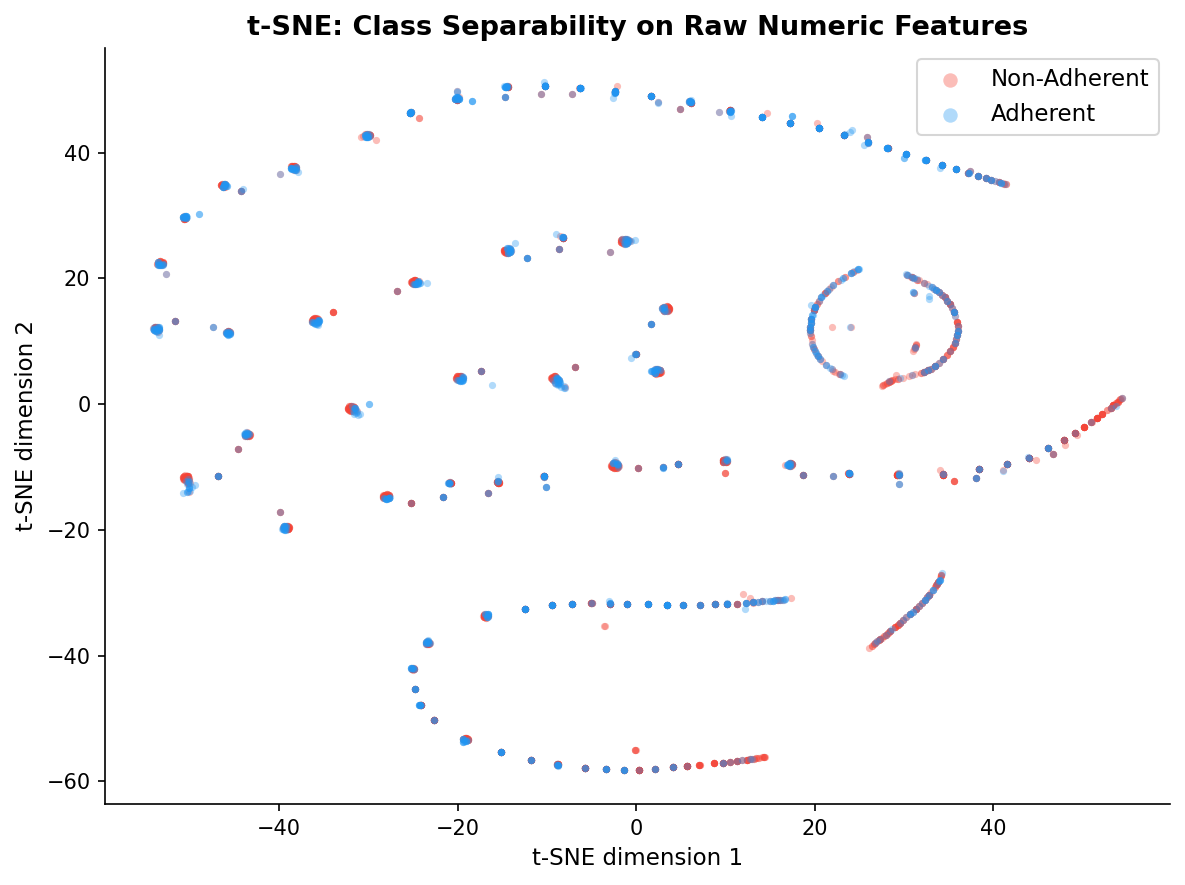


Interpretation:
  Clear cluster separation → strong feature signal for classification.
  Intermingled clusters    → classification will be harder; richer features needed.


In [36]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, name, colour in [
    (0, "Non-Adherent", PALETTE["non_adherent"]),
    (1, "Adherent",     PALETTE["adherent"])
]:
    mask_tsne = y_plot == label
    ax.scatter(X_2d[mask_tsne, 0], X_2d[mask_tsne, 1],
               c=colour, label=name, alpha=0.35, s=12, linewidths=0)

ax.set_title("t-SNE: Class Separability on Raw Numeric Features", fontweight="bold")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(markerscale=2, fontsize=11)
plt.tight_layout()
save_figure(fig, "tsne_class_separability.png")
plt.show()

print("\nInterpretation:")
print("  Clear cluster separation → strong feature signal for classification.")
print("  Intermingled clusters    → classification will be harder; richer features needed.")

---
## 10. EDA Summary and Implications for Modelling

The table below summarises the key findings from this notebook and draws out the implications for the modelling decisions made in Notebooks 02 through 05.

In [37]:
section("10. EDA Key Findings")

print("""
╔════════════════════════════════════════════════════════════════════════╗
║                        EDA KEY FINDINGS                                ║
╠════════════════════════════════════════════════════════════════════════╣
║  Dataset size          : 24,084 patients (13 duplicates removed)       ║
║  Missing values        : None; dataset is complete                     ║
║  Duplicate rows        : 13 removed                                    ║
║                                                                        ║
║  CLASS BALANCE                                                         ║
║  Adherent (1)          : 9,669 (40.2%)                                 ║
║  Non-adherent (0)      : 14,415 (59.8%)                                ║
║  Imbalance ratio       : 1.49x (mild)                                  ║
║  → SMOTE needed        : Mild: apply during training in Notebook 03    ║
║                                                                        ║
║  FEATURE SIGNAL (Mann-Whitney U, rank-biserial r)                      ║
║  Strongest predictor   : unitstotal (r = 0.71)                         ║
║  Second strongest      : annualclaimamount (r = 0.63)                  ║
║  Moderate effect       : age (r = 0.29)                                ║
║  Weak effect           : annualcontribution (r = 0.06)                 ║
║  All p-values < 0.05                                                   ║
║                                                                        ║
║  DISTRIBUTION NOTES                                                    ║
║  Highly skewed features  : annualclaimamount (skew > 150),             ║
║                            unitstotal (skew > 100)                     ║
║  → Going to use RobustScaler for these features in Notebook 03         ║
║                                                                        ║
║  CONDITION BREAKDOWN                                                   ║
║  Adherence rate — Diabetes        : 43.9%                              ║
║  Adherence rate — Hypertension    : 39.2%                              ║
║  → Hypertension patients are less adherent; consistent with the        ║
║    'I feel fine' discontinuation pattern documented in the literature  ║
║                                                                        ║
║  t-SNE IMPRESSION                                                      ║
║  Class separability    : Moderate (clusters overlap but show)          ║
║                          directional separation, confirming that       ║
║                          engineered features will be important         ║
╚════════════════════════════════════════════════════════════════════════╝
""")



──────────────────────────────────────────────────────────────────────
  10. EDA Key Findings
──────────────────────────────────────────────────────────────────────

╔════════════════════════════════════════════════════════════════════════╗
║                        EDA KEY FINDINGS                                ║
╠════════════════════════════════════════════════════════════════════════╣
║  Dataset size          : 24,084 patients (13 duplicates removed)       ║
║  Missing values        : None; dataset is complete                     ║
║  Duplicate rows        : 13 removed                                    ║
║                                                                        ║
║  CLASS BALANCE                                                         ║
║  Adherent (1)          : 9,669 (40.2%)                                 ║
║  Non-adherent (0)      : 14,415 (59.8%)                                ║
║  Imbalance ratio       : 1.49x (mild)                                  ║
║  → SMO

---
## 11. Save Cleaned Dataset and Push to GitHub

The cleaned dataframe is saved as a pickle file so that Notebook 02 (Feature Engineering) can load it directly without repeating any of the steps above. Pickle is used rather than CSV because it preserves the Python dtypes (including `bool` columns and `category` dtype) exactly as set during cleaning.

In [40]:
section("11. Save cleaned.pkl")

out_path = os.path.join(DATA_PROC, "cleaned2.pkl")

with open(out_path, "wb") as f:
    pickle.dump(df, f)

print(f"Saved: {out_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumns saved:")
for c in df.columns:
    print(f"  {c}  ({df[c].dtype})")


──────────────────────────────────────────────────────────────────────
  11. Save cleaned.pkl
──────────────────────────────────────────────────────────────────────
Saved: /content/diabetes-hypertension-medication-adherence/data/processed/cleaned2.pkl
Shape: 24,071 rows × 12 columns

Columns saved:
  adherence  (int64)
  age  (int64)
  annualcontribution  (float64)
  annualclaimamount  (float64)
  unitstotal  (float64)
  gender_m  (bool)
  schemetype_medium  (bool)
  schemetype_premium  (bool)
  diagnosis_hypertension  (bool)
  covertype_standard  (bool)
  comorbidity_no_comorbidity  (bool)
  complicationdevelopment_no_complication  (bool)


In [42]:
section("11. Verification: reload and confirm")

with open(os.path.join(DATA_PROC, "cleaned.pkl"), "rb") as f:
    df_check = pickle.load(f)

assert df_check.shape == df.shape, "Shape mismatch after reload!"
assert list(df_check.columns) == list(df.columns), "Column mismatch after reload!"
print(f"Verification passed. cleaned.pkl is intact: {df_check.shape}")
print("\nNotebook 01 complete. Proceed to 02_Feature_Engineering.ipynb.")


──────────────────────────────────────────────────────────────────────
  11. Verification: reload and confirm
──────────────────────────────────────────────────────────────────────
Verification passed. cleaned.pkl is intact: (24071, 12)

Notebook 01 complete. Proceed to 02_Feature_Engineering.ipynb.


In [82]:
# Copy notebook from Colab to repo, commit and push


import shutil
from pathlib import Path

NB_NAME  = "01_EDA_dmhtn.ipynb"
COLAB_NB = Path(f"/content/drive/MyDrive/Colab Notebooks/{NB_NAME}")
REPO_NB  = Path(REPO_DIR) / "notebooks" / NB_NAME
REPO_NB.parent.mkdir(parents=True, exist_ok=True)

if COLAB_NB.exists():
    shutil.copy(COLAB_NB, REPO_NB)
    print(f"Copied → {REPO_NB}")

assert REPO_NB.exists(), f"Copy failed: {REPO_NB} not found"

%cd {REPO_DIR}
!git add notebooks/ figures/ data/processed/cleaned.pkl
!git status
!git commit -m "NB01: EDA complete; cleaned.pkl saved"
!git push
print("Done, Notebook 01 committed and pushed.")

Copied → /content/diabetes-hypertension-medication-adherence/notebooks/01_EDA_dmhtn.ipynb
/content/diabetes-hypertension-medication-adherence
The following paths are ignored by one of your .gitignore files:
data/processed
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   figures/eda/adherence_by_condition.png
	new file:   figures/eda/boxplots_by_class.png
	new file:   figures/eda/class_balance.png
	new file:   figures/eda/correlation_matrix.png
	new file:   figures/eda/feature_target_correlation.png
	new file:   figures/eda/numeric_distributions.png
	new file:   figures/eda/tsne_class_separability.png
	new file:   notebooks/01_EDA_dmhtn.ipynb

[main 4b7a6c0] NB01: EDA complete; cleaned.pkl saved
 8 files changed, 1 insertion(+)
 create mode 100644 figures/e

In [81]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	figures/
	notebooks/

nothing added to commit but untracked files present (use "git add" to track)


In [1]:
# 1. Erase the last commit from your local Colab environment history
!git reset --hard HEAD~1

# 2. Force-push to overwrite the remote history on GitHub
# Replace 'main' with your specific branch name if it is different
!git push origin main --force


fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
